# 06 — Regex Chunk Audit (D-05, canonical)

> **Phase 4 · SSOT §12.5 D-05 Regex Chunk Measurement**
> **Canonical artifact**: `data/registry/CHUNK_O200K_BASE_v001.parquet` (SSOT §38 naming)

> **Tokenizer authority**: D-04 `TOKEN_O200K_BASE_v001`.
> This notebook does **not** re-derive token counts, token premium, or any §8 decomposition term.
> It measures only the *first* stage of SSOT §5 — the pretokenization map `P_v` — and how the
> final subword tokens distribute across those chunks.

## Scope (SSOT §5.1)

형태소 분석 ≠ regex chunking ≠ subword tokenization. 세 경계는 일치할 필요가 없다.

* **In scope**: `o200k_base` pat_str이 만드는 chunk 경계, chunk 개수/바이트 분포,
  chunk당 token 수, chunk 유형 구성비 (letter / number / punctuation / whitespace).
* **Out of scope**: token ID 배열, token count authority, TokenPremium 및 그 §8 분해항.
  이들은 D-04가 유일한 authority이며 D-05 schema에 존재하지 않는다 (아래 §5에서 실증).

## Why this is a mechanism audit, not an outcome table

RQ5(MN-02)는 "왜 한국어가 더 많은 token으로 쪼개지는가"를 묻는다. D-04는 *얼마나*를 답하고,
D-05는 그 앞단에서 *어디서 쪼개지는가*를 답한다. 두 층이 분리되어 있어야 mechanism 주장이
outcome 측정을 순환 참조하지 않는다.

## 0 — Environment, lineage gate, and rebuild gate

In [1]:
from __future__ import annotations

import hashlib
import json

import duckdb
import pandas as pd

from tokenization_premium.chunking import (
    CHUNK_RELATIVE_PATH,
    CHUNK_SCHEMA_VERSION,
    CHUNK_TYPES,
    CHUNKING_CONFIG,
    CHUNKING_CONFIG_SHA256,
    assert_tokenizer_identity,
    chunk_pattern,
    chunk_schema,
    classify_chunk,
    regex_chunks,
    side_chunk_features,
    validate_chunk_measurements,
)
from tokenization_premium.hashing import sha256_file
from tokenization_premium.lineage import (
    ADJUDICATION_COMMIT,
    ADJUDICATION_DOC,
    CANONICAL_ARTIFACTS,
    CANONICAL_PAIR_SET_MD5,
    assert_canonical_artifact,
    pair_set_md5,
)
from tokenization_premium.paths import PROJECT_ROOT
from tokenization_premium.tokenizer_measurement import (
    PAT_STR_SHA256,
    TIKTOKEN_VERSION,
    TOKENIZER_ID,
    load_o200k_base_offline,
)

pd.set_option("display.width", 200, "display.max_columns", 60)


# 전집단 질의는 DuckDB pushdown으로 처리해 메모리를 bounded 상태로 유지한다.
def connect() -> duckdb.DuckDBPyConnection:
    con = duckdb.connect()
    con.execute("SET memory_limit='4GB'")
    con.execute("SET threads=8")
    con.execute("SET preserve_insertion_order=false")
    spill = PROJECT_ROOT / ".runtime" / "nb06" / "duckdb-spill"
    spill.mkdir(parents=True, exist_ok=True)
    con.execute(f"SET temp_directory='{spill.as_posix()}'")
    return con


CON = connect()
CHUNK_PATH = PROJECT_ROOT / CHUNK_RELATIVE_PATH
TOKEN_PATH = CANONICAL_ARTIFACTS["TOKEN_O200K_BASE_v001"].path
PAIR_PATH = CANONICAL_ARTIFACTS["PAIR_REGISTRY_v002"].path
CHUNK_REL = f"read_parquet('{CHUNK_PATH.as_posix()}')"
TOKEN_REL = f"read_parquet('{TOKEN_PATH.as_posix()}')"
PAIR_REL = f"read_parquet('{PAIR_PATH.as_posix()}')"

print(f"lineage authority : {ADJUDICATION_COMMIT}")
print(f"                    {ADJUDICATION_DOC}")
print(f"canonical pair set: md5 {CANONICAL_PAIR_SET_MD5}")

lineage authority : 441d5802bfebe178fd220d08b653c60dfad17faf
                    ssot/2026-08-17_1730_KOEN_TP_G2_G3_G4_FINAL_ADJUDICATION.md
canonical pair set: md5 d9660d654ee449e4d0c23a0070225274


In [2]:
REBUILD_CANONICAL_ARTIFACT = False   # Director-authorized rebuild only; Run All must never regenerate

if REBUILD_CANONICAL_ARTIFACT:
    raise RuntimeError(
        "REBUILD_CANONICAL_ARTIFACT=True는 Director 승인 실행에서만 사용한다. "
        "기본 Run All은 canonical artifact를 재생성하지 않고 검증·재사용만 한다."
    )
print("rebuild gate: DISABLED (validate/reuse only)")

rebuild gate: DISABLED (validate/reuse only)


### 0.1 — Upstream identity is verified, not assumed

D-05의 모든 행은 D-04 행에 1:1로 붙는다. 따라서 upstream artifact의 물리적 신원이
Claude-B가 독립 재계산한 값과 다르면 이 노트북은 여기서 즉시 멈춘다 (fail-closed).

In [3]:
TOK = assert_canonical_artifact("TOKEN_O200K_BASE_v001", con=CON)
PAIR = assert_canonical_artifact("PAIR_REGISTRY_v002", con=CON)

for name, rec in (("TOKEN_O200K_BASE_v001", TOK), ("PAIR_REGISTRY_v002", PAIR)):
    print(f"{name:26s} rows={rec['row_count']:>10,}  cols={rec['column_count']:>3}  "
          f"sha256={rec['sha256'][:16]}…  {rec['identity']}")

TOKEN_O200K_BASE_v001      rows= 3,835,988  cols= 28  sha256=1c30e3276222dd94…  CANONICAL_ARTIFACT_IDENTITY_VERIFIED
PAIR_REGISTRY_v002         rows= 5,652,925  cols= 69  sha256=95f523d11b0e8fcf…  CANONICAL_ARTIFACT_IDENTITY_VERIFIED


## 1 — Configuration freeze (SSOT §4, §14)

D-05는 새 tokenizer 설정을 도입하지 않는다. pat_str을 문헌에서 옮겨 적지 않고
**encoder 객체에서 직접 읽어** D-04가 동결한 hash와 대조한다. 불일치 시
`ChunkConfigMismatch`로 즉시 실패한다.

In [4]:
ENC = load_o200k_base_offline(PROJECT_ROOT / ".runtime/tiktoken-cache")
IDENTITY = assert_tokenizer_identity(ENC)          # pat_str hash 불일치 시 여기서 raise
PATTERN = chunk_pattern(ENC)

live_pat_hash = hashlib.sha256(PATTERN.pattern.encode("utf-8")).hexdigest()
print(f"tokenizer_id        : {TOKENIZER_ID}  (tiktoken {TIKTOKEN_VERSION})")
print(f"pat_str sha256 D-04 : {PAT_STR_SHA256}")
print(f"pat_str sha256 live : {live_pat_hash}")
print(f"MATCH               : {live_pat_hash == PAT_STR_SHA256}")
print(f"chunking config sha : {CHUNKING_CONFIG_SHA256}")
print()
print("Track A 제약 (SSOT §25):")
print(f"  special_tokens_used = {CHUNKING_CONFIG['special_tokens_used']}")
print(f"  chat_template_used  = {CHUNKING_CONFIG['chat_template_used']}")
print(f"  authority_note      = {CHUNKING_CONFIG['authority_note']}")

tokenizer_id        : o200k_base  (tiktoken 0.13.0)
pat_str sha256 D-04 : 2d1b8dc11e89af71459b36004f698ab3693f59fd84f63e8ec2b49564ab857420
pat_str sha256 live : 2d1b8dc11e89af71459b36004f698ab3693f59fd84f63e8ec2b49564ab857420
MATCH               : True
chunking config sha : b8f26abf3e64a1d7d91284e7ccdda0a27a1d615052d86c304c9f7196e7f7dbf5

Track A 제약 (SSOT §25):
  special_tokens_used = False
  chat_template_used  = False
  authority_note      = D-04가 최종 token ID/count/TP의 authority다. D-05는 mechanism 측정이다.


## 2 — What `P_v` actually does (worked example, computed here)

아래는 노트북이 직접 계산하는 예시다. 한국어 조사·어미가 letter chunk 안에서 어떻게
묶이고, 그 chunk 하나가 몇 개의 subword token으로 다시 쪼개지는지를 보여준다.
이것이 D-05가 측정하는 유일한 대상이다.

In [5]:
DEMO = "학교에서 친구들과 함께 공부했습니다."
DEMO_EN = "I studied together with my friends at school."

rows = []
for label, text in (("KO", DEMO), ("EN", DEMO_EN)):
    for i, chunk in enumerate(regex_chunks(text, encoding=ENC)):
        ids = ENC.encode(chunk)
        rows.append({"side": label, "i": i, "chunk": repr(chunk),
                     "bytes": len(chunk.encode("utf-8")), "type": classify_chunk(chunk),
                     "n_tokens": len(ids),
                     "tokens": [ENC.decode([t]) for t in ids]})
demo_df = pd.DataFrame(rows)
display(demo_df)

for label, text in (("KO", DEMO), ("EN", DEMO_EN)):
    chunks = regex_chunks(text, encoding=ENC)
    print(f"{label}: chunks={len(chunks):3d}  tokens={len(ENC.encode(text)):3d}  "
          f"tokens/chunk={len(ENC.encode(text)) / len(chunks):.3f}")

,side,i,chunk,bytes,type,n_tokens,tokens
0,KO,0,'학교에서',12,letter,2,"[학교, 에서]"
1,KO,1,' 친구들과',13,letter,2,"[ 친구, 들과]"
2,KO,2,' 함께',7,letter,1,[ 함께]
3,KO,3,' 공부했습니다',19,letter,2,"[ 공부, 했습니다]"
4,KO,4,'.',1,punctuation,1,[.]
5,EN,0,'I',1,letter,1,[I]
6,EN,1,' studied',8,letter,1,[ studied]
7,EN,2,' together',9,letter,1,[ together]
8,EN,3,' with',5,letter,1,[ with]
9,EN,4,' my',3,letter,1,[ my]


KO: chunks=  5  tokens=  8  tokens/chunk=1.600
EN: chunks=  9  tokens=  9  tokens/chunk=1.000


## 3 — §5 invariants, recomputed live on a canonical sample

manifest가 "통과했다"고 말하는 것을 믿지 않는다. 이 셀은 canonical artifact에서
결정적 표본을 직접 뽑아 여섯 불변식을 **여기서 다시 계산한다**.

| # | 불변식 |
|---|---|
| 1 | `concat(chunks) == text` (손실/중복 span 0) |
| 2 | 빈 chunk 0 |
| 3 | chunk 순서 결정성 |
| 4 | flatten(per-chunk encode) == D-04 저장 token ID 배열 |
| 5 | `chunk_token_total == len(D-04 token ids)` |
| 6 | chunk 유형이 4범주 안에 있고 구성비 합 = 1 |

불변식 4가 핵심이다. 이것이 성립해야 "D-05의 chunk가 D-04의 token을 실제로 설명한다"고
말할 수 있고, 성립하지 않으면 D-05는 D-04와 무관한 두 번째 측정이 되어 버린다.

In [6]:
NB_SAMPLE_N = 3_000
NB_SALT = "NB06_LIVE_CHECK_v001"     # pilot salt와 다른 값 — pilot 표본을 그대로 재사용하지 않는다

sample = CON.execute(f"""
    SELECT t.pair_id, p.ko_text_analysis AS ko, p.en_text_analysis AS en,
           t.ko_token_ids, t.en_token_ids
    FROM {TOKEN_REL} t JOIN {PAIR_REL} p USING (pair_id)
    ORDER BY md5(t.pair_id || '{NB_SALT}') LIMIT {NB_SAMPLE_N}
""").fetchall()

inv = dict.fromkeys(
    ["1_concat_mismatch", "2_empty_chunk", "3_nondeterministic_order",
     "4_token_id_mismatch", "5_token_count_mismatch", "6_type_share_not_one"], 0)
chunks_seen = 0

for _pair_id, ko, en, ko_ids, en_ids in sample:
    for text, stored in ((ko, list(ko_ids)), (en, list(en_ids))):
        chunks = regex_chunks(text, encoding=ENC)
        chunks_seen += len(chunks)
        if "".join(chunks) != text:
            inv["1_concat_mismatch"] += 1
        if any(not c for c in chunks):
            inv["2_empty_chunk"] += 1
        if chunks != regex_chunks(text, encoding=ENC):
            inv["3_nondeterministic_order"] += 1
        feats = side_chunk_features(text, encoding=ENC)
        if feats.pop("_flat_tokens") != stored:
            inv["4_token_id_mismatch"] += 1
        if feats["chunk_token_total"] != len(stored):
            inv["5_token_count_mismatch"] += 1
        share = sum(feats[f"chunk_type_share_{t}"] for t in CHUNK_TYPES)
        if abs(share - 1.0) > 1e-9:
            inv["6_type_share_not_one"] += 1

print(f"live sample        : {len(sample):,} pairs  ({chunks_seen:,} chunks)")
for key, value in inv.items():
    print(f"  {key:28s} {value}")
NB_LIVE_MISMATCH = sum(inv.values())
print(f"\nLIVE TOTAL MISMATCH : {NB_LIVE_MISMATCH}")
assert NB_LIVE_MISMATCH == 0, "노트북 재계산에서 §5 불변식 위반 — D-05를 신뢰할 수 없다"

live sample        : 3,000 pairs  (98,222 chunks)
  1_concat_mismatch            0
  2_empty_chunk                0
  3_nondeterministic_order     0
  4_token_id_mismatch          0
  5_token_count_mismatch       0
  6_type_share_not_one         0

LIVE TOTAL MISMATCH : 0


## 4 — Full-population artifact validation

전집단 artifact를 물리적으로 재검증한다. 여기서 확인하는 것:

* row/`pair_id`/`chunk_measurement_id` 수와 유일성
* D-04 cohort와의 양방향 anti-join = 0 (누락도 잉여도 없음)
* pair-set md5가 canonical 값과 동일
* 설정 열(`chunking_config_sha256` 등)이 단일 값
* schema 버전·열 수, 그리고 파일 sha256이 manifest와 일치

In [7]:
MANIFEST = json.loads(
    (PROJECT_ROOT / "outputs/manifests/CHUNK_O200K_BASE_MANIFEST_v001.json").read_text(
        encoding="utf-8"))
EXPECTED_ROWS = MANIFEST["output"]["row_count"]

validate_chunk_measurements(CHUNK_PATH, expected_rows=EXPECTED_ROWS)   # 실패 시 raise
print(f"validate_chunk_measurements: PASS  (expected_rows={EXPECTED_ROWS:,})")

counts = CON.execute(f"""
    SELECT count(*) AS rows, count(DISTINCT pair_id) AS pairs,
           count(DISTINCT chunk_measurement_id) AS ids,
           count(DISTINCT tokenizer_measurement_id) AS fk,
           count(DISTINCT chunking_config_sha256) AS cfg,
           count(DISTINCT pat_str_sha256) AS pat_str_n,
           sum(CASE WHEN analysis_warning_flag THEN 1 ELSE 0 END) AS warnings,
           sum(CASE WHEN NOT token_equivalence_ok THEN 1 ELSE 0 END) AS token_bad,
           sum(CASE WHEN NOT chunk_reconstruction_ok THEN 1 ELSE 0 END) AS recon_bad
    FROM {CHUNK_REL}
""").df()
display(counts)

missing = CON.execute(
    f"SELECT count(*) FROM {TOKEN_REL} t ANTI JOIN {CHUNK_REL} c USING (pair_id)").fetchone()[0]
extra = CON.execute(
    f"SELECT count(*) FROM {CHUNK_REL} c ANTI JOIN {TOKEN_REL} t USING (pair_id)").fetchone()[0]
pair_md5 = pair_set_md5(CHUNK_PATH, CON)   # 해시 정의는 registry helper 하나만 쓴다
artifact_sha = sha256_file(CHUNK_PATH)

print(f"D-04 -> D-05 missing      : {missing}")
print(f"D-05 -> D-04 extra        : {extra}")
print(f"pair-set md5              : {pair_md5}")
print(f"canonical pair-set md5    : {CANONICAL_PAIR_SET_MD5}   MATCH={pair_md5 == CANONICAL_PAIR_SET_MD5}")
print(f"schema version            : {CHUNK_SCHEMA_VERSION}  ({len(chunk_schema().names)} columns)")
print(f"artifact sha256           : {artifact_sha}")
print(f"manifest  sha256          : {MANIFEST['output']['sha256']}   "
      f"MATCH={artifact_sha == MANIFEST['output']['sha256']}")

if not (artifact_sha == MANIFEST["output"]["sha256"]
        and pair_md5 == CANONICAL_PAIR_SET_MD5
        and int(missing) == 0 and int(extra) == 0
        and int(counts["token_bad"].iloc[0]) == 0
        and int(counts["recon_bad"].iloc[0]) == 0):
    raise RuntimeError("D-05 canonical artifact identity/invariant mismatch — 이후 셀을 신뢰할 수 없다")
print()
print("CANONICAL_ARTIFACT_IDENTITY_VERIFIED")

validate_chunk_measurements: PASS  (expected_rows=3,835,988)


,rows,pairs,ids,fk,cfg,pat_str_n,warnings,token_bad,recon_bad
0,3835988,3835988,3835988,3835988,1,1,0.0,0.0,0.0


D-04 -> D-05 missing      : 0
D-05 -> D-04 extra        : 0
pair-set md5              : d9660d654ee449e4d0c23a0070225274
canonical pair-set md5    : d9660d654ee449e4d0c23a0070225274   MATCH=True
schema version            : CHUNK_O200K_BASE_v001  (39 columns)
artifact sha256           : bfa98bd6cf7ee8b7254c469aed3e259ce43cc8f0529153347ca4c2c3fc1944ab
manifest  sha256          : bfa98bd6cf7ee8b7254c469aed3e259ce43cc8f0529153347ca4c2c3fc1944ab   MATCH=True

CANONICAL_ARTIFACT_IDENTITY_VERIFIED


## 5 — Scope boundary, asserted mechanically

D-05가 두 번째 token authority가 되지 않았음을 주장이 아니라 검사로 확인한다.
schema에 token ID 배열·TokenPremium·§8 분해항이 존재하면 이 셀이 실패한다.

In [8]:
FORBIDDEN = ("ko_token_ids", "en_token_ids", "token_premium", "log_token_premium",
             "compression_penalty", "code_point_ratio", "byte_density_ratio")
schema_names = set(chunk_schema().names)
leaked = sorted(schema_names & set(FORBIDDEN))
assert not leaked, f"D-05 schema가 D-04 authority를 침범했다: {leaked}"

parquet_cols = set(CON.execute(f"SELECT * FROM {CHUNK_REL} LIMIT 0").df().columns)
assert parquet_cols == schema_names, "물리 parquet 열과 schema 정의가 다르다"

print(f"D-05 columns              : {len(schema_names)}")
print(f"forbidden columns present : {leaked or 'none'}")
print(f"physical == declared      : {parquet_cols == schema_names}")
print("D-04는 token/TP의 단일 authority로 유지된다.")

D-05 columns              : 39
forbidden columns present : none
physical == declared      : True
D-04는 token/TP의 단일 authority로 유지된다.


## 6 — Population-level chunk structure (KO vs EN)

여기부터가 D-05가 실제로 기여하는 내용이다. 전집단에서 두 언어의 pretokenization
구조가 어떻게 다른지 본다. 해석은 NB08에서 다루며, 이 노트북은 측정값만 제시한다.

In [9]:
summary = CON.execute(f"""
    SELECT
      'KO' AS side, avg(ko_chunk_count) AS mean_chunks,
      median(ko_chunk_count) AS p50_chunks, avg(ko_tokens_per_chunk) AS mean_tokens_per_chunk,
      avg(ko_mean_chunk_bytes) AS mean_chunk_bytes, avg(ko_p90_chunk_bytes) AS mean_p90_bytes,
      avg(ko_chunk_type_share_letter) AS share_letter,
      avg(ko_chunk_type_share_number) AS share_number,
      avg(ko_chunk_type_share_punctuation) AS share_punct,
      avg(ko_chunk_type_share_whitespace) AS share_space
    FROM {CHUNK_REL}
    UNION ALL
    SELECT
      'EN', avg(en_chunk_count), median(en_chunk_count), avg(en_tokens_per_chunk),
      avg(en_mean_chunk_bytes), avg(en_p90_chunk_bytes),
      avg(en_chunk_type_share_letter), avg(en_chunk_type_share_number),
      avg(en_chunk_type_share_punctuation), avg(en_chunk_type_share_whitespace)
    FROM {CHUNK_REL}
""").df().set_index("side").round(4)
display(summary)

ratio = CON.execute(f"""
    SELECT avg(pair_chunk_ratio) AS mean_ko_over_en_chunks,
           median(pair_chunk_ratio) AS p50_ko_over_en_chunks,
           avg(ko_tokens_per_chunk) / avg(en_tokens_per_chunk) AS tokens_per_chunk_ratio
    FROM {CHUNK_REL}
""").df().round(4)
display(ratio)

,mean_chunks,p50_chunks,mean_tokens_per_chunk,mean_chunk_bytes,mean_p90_bytes,share_letter,share_number,share_punct,share_space
side,,,,,,,,,
KO,13.5611,11.0,2.0186,8.1240,13.9620,0.8168,0.0240,0.1477,0.0114
EN,19.4989,15.0,1.0365,4.9396,8.8116,0.8525,0.0149,0.1228,0.0098


,mean_ko_over_en_chunks,p50_ko_over_en_chunks,tokens_per_chunk_ratio
0,0.7112,0.7,1.9475


### 6.1 — Chunk 축과 token 축의 분해

한 쌍의 KO/EN token 수 비는 두 항의 곱으로 정확히 분해된다.

$$\frac{N_{ko}}{N_{en}} = \underbrace{\frac{C_{ko}}{C_{en}}}_{\text{chunk 수 비}}
\times \underbrace{\frac{N_{ko}/C_{ko}}{N_{en}/C_{en}}}_{\text{chunk당 token 수 비}}$$

이 항등식은 정의상 성립하므로 새로운 주장이 아니다. 유용한 점은 **어느 항이 큰지**가
"한국어가 더 많은 token으로 쪼개지는 이유"를 chunk 경계 쪽과 chunk 내부 분할 쪽으로
나눠 보여준다는 것이다. 아래에서 항등식이 수치적으로 성립하는지도 확인한다.

In [10]:
decomp = CON.execute(f"""
    SELECT
      avg(ln(ko_chunk_count::DOUBLE / en_chunk_count)) AS mean_log_chunk_term,
      avg(ln(ko_tokens_per_chunk / en_tokens_per_chunk)) AS mean_log_density_term,
      avg(ln(ko_chunk_token_total::DOUBLE / en_chunk_token_total)) AS mean_log_token_ratio,
      max(abs(ln(ko_chunk_count::DOUBLE / en_chunk_count)
              + ln(ko_tokens_per_chunk / en_tokens_per_chunk)
              - ln(ko_chunk_token_total::DOUBLE / en_chunk_token_total))) AS max_identity_residual
    FROM {CHUNK_REL}
""").df()
display(decomp.round(8))

resid = float(decomp["max_identity_residual"].iloc[0])
print(f"max |residual| = {resid:.3e}")
assert resid < 1e-9, "chunk/density 분해 항등식이 수치적으로 성립하지 않는다"

chunk_term = float(decomp["mean_log_chunk_term"].iloc[0])
density_term = float(decomp["mean_log_density_term"].iloc[0])
total = chunk_term + density_term
# 두 항의 부호가 반대일 수 있으므로 '총합 대비 비율'로 제시하지 않는다.
# 그런 경우 100%를 넘는 수치가 나와 오독을 부른다. 크기와 방향을 그대로 보고한다.
print(f"mean log(N_ko / N_en)          : {total:+.4f}")
print(f"  chunk-count 축  log(C_ko/C_en): {chunk_term:+.4f}  "
      f"({'KO에 chunk가 더 적다' if chunk_term < 0 else 'KO에 chunk가 더 많다'})")
print(f"  chunk당 token 축              : {density_term:+.4f}  "
      f"({'KO chunk가 더 잘게 쪼개진다' if density_term > 0 else 'EN chunk가 더 잘게 쪼개진다'})")
print(f"  두 항의 부호                  : "
      f"{'반대 (상쇄)' if chunk_term * density_term < 0 else '같음 (누적)'}")
print(f"  |chunk 축| : |token/chunk 축|  = "
      f"{abs(chunk_term):.4f} : {abs(density_term):.4f}")

,mean_log_chunk_term,mean_log_density_term,mean_log_token_ratio,max_identity_residual
0,-0.367158,0.652335,0.285177,0.0


max |residual| = 4.718e-16
mean log(N_ko / N_en)          : +0.2852
  chunk-count 축  log(C_ko/C_en): -0.3672  (KO에 chunk가 더 적다)
  chunk당 token 축              : +0.6523  (KO chunk가 더 잘게 쪼개진다)
  두 항의 부호                  : 반대 (상쇄)
  |chunk 축| : |token/chunk 축|  = 0.3672 : 0.6523


### 6.2 — Distribution figure

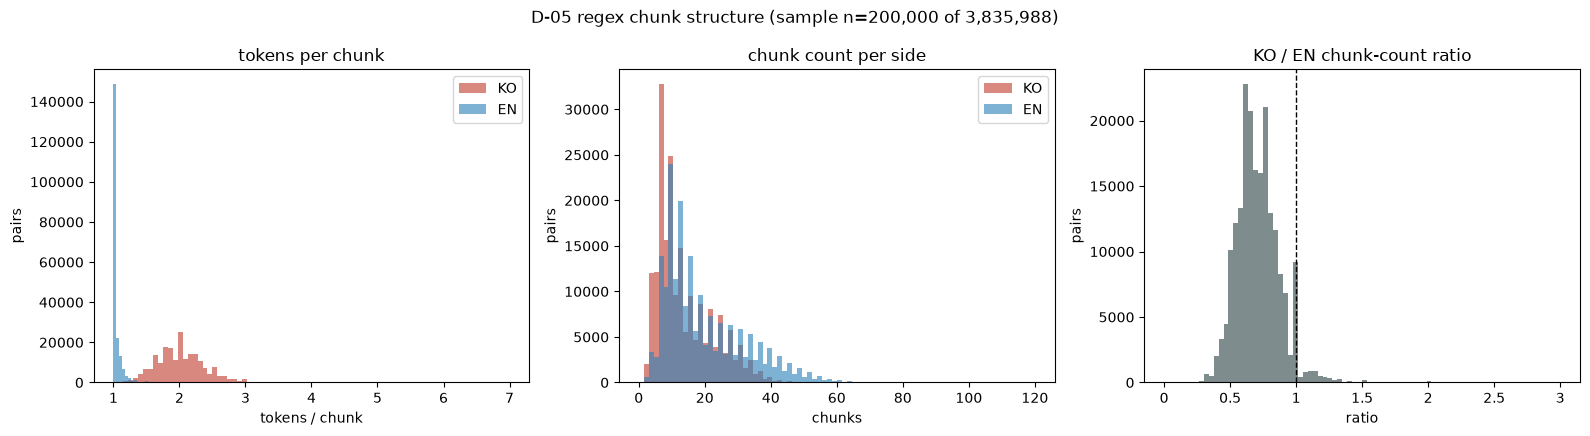

font: {'family': 'NanumGothic', 'path': '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'}


In [11]:
from tokenization_premium.visualization import find_korean_font  # noqa: E402

FONT = find_korean_font()
%matplotlib inline
import matplotlib.pyplot as plt  # noqa: E402
from matplotlib.ticker import FuncFormatter  # noqa: E402

plt.rcParams["axes.unicode_minus"] = False

hist = CON.execute(f"""
    SELECT ko_tokens_per_chunk, en_tokens_per_chunk,
           ko_chunk_count, en_chunk_count, pair_chunk_ratio
    FROM {CHUNK_REL} USING SAMPLE 200000 ROWS (reservoir, 20260817)
""").df()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
plain = FuncFormatter(lambda v, _: f"{v:g}")

axes[0].hist(hist["ko_tokens_per_chunk"], bins=80, alpha=0.6, label="KO", color="#c0392b")
axes[0].hist(hist["en_tokens_per_chunk"], bins=80, alpha=0.6, label="EN", color="#2980b9")
axes[0].set_title("tokens per chunk")
axes[0].set_xlabel("tokens / chunk")
axes[0].legend()

axes[1].hist(hist["ko_chunk_count"], bins=80, range=(0, 120), alpha=0.6, label="KO",
             color="#c0392b")
axes[1].hist(hist["en_chunk_count"], bins=80, range=(0, 120), alpha=0.6, label="EN",
             color="#2980b9")
axes[1].set_title("chunk count per side")
axes[1].set_xlabel("chunks")
axes[1].legend()

axes[2].hist(hist["pair_chunk_ratio"], bins=80, range=(0, 3), color="#7f8c8d")
axes[2].axvline(1.0, color="k", lw=1, ls="--")
axes[2].set_title("KO / EN chunk-count ratio")
axes[2].set_xlabel("ratio")

for ax in axes:
    ax.set_ylabel("pairs")
    ax.xaxis.set_major_formatter(plain)
    ax.yaxis.set_major_formatter(plain)

fig.suptitle(f"D-05 regex chunk structure (sample n={len(hist):,} of {EXPECTED_ROWS:,})")
fig.tight_layout()
plt.show()
print(f"font: {FONT}")

## 7 — Closeout

이 노트북이 실제로 계산해 확인한 것:

1. tokenizer/pat_str 신원이 D-04 동결값과 동일 (§1, live hash 대조)
2. `P_v` 예시 계산 (§2)
3. §5 여섯 불변식을 canonical 표본에서 **재계산** → 위반 0 (§3)
4. 전집단 artifact 재검증: 행 수·유일성·anti-join·pair-set md5·sha256 (§4)
5. D-05가 token authority를 침범하지 않음을 schema 검사로 확인 (§5)
6. 전집단 chunk 구조와 chunk/density 축 분해 (§6)

**하지 않은 것**: token 수 재산출, TokenPremium 재계산, §8 분해항 재정의, 해석적 결론.
RQ5 해석은 NB08 소관이다.

In [12]:
CLOSEOUT = {
    "notebook": "notebooks/06_regex_chunk_audit.ipynb",
    "dataset_contract": "D-05 (SSOT §12.5)",
    "canonical_artifact": str(CHUNK_RELATIVE_PATH),
    "schema_version": CHUNK_SCHEMA_VERSION,
    "column_count": len(chunk_schema().names),
    "row_count": EXPECTED_ROWS,
    "artifact_sha256": artifact_sha,
    "pair_set_md5": pair_md5,
    "pair_set_matches_canonical": pair_md5 == CANONICAL_PAIR_SET_MD5,
    "tokenizer_id": TOKENIZER_ID,
    "pat_str_sha256": PAT_STR_SHA256,
    "chunking_config_sha256": CHUNKING_CONFIG_SHA256,
    "live_recheck_pairs": len(sample),
    "live_recheck_mismatch": NB_LIVE_MISMATCH,
    "full_run_token_equivalence_mismatches": MANIFEST["token_equivalence_mismatches"],
    "full_run_warnings": MANIFEST["warnings"],
    "r1_periodic_sampling": MANIFEST["runtime_telemetry"]["r1_periodic_sampling"],
    "r1_sample_count": MANIFEST["runtime_telemetry"]["sample_count"],
    "r1_min_mem_available_gib": MANIFEST["runtime_telemetry"]["min_mem_available_gib"],
    "d04_remains_token_authority": True,
}
print(json.dumps(CLOSEOUT, ensure_ascii=False, indent=2))
CON.close()

{
  "notebook": "notebooks/06_regex_chunk_audit.ipynb",
  "dataset_contract": "D-05 (SSOT §12.5)",
  "canonical_artifact": "data/registry/CHUNK_O200K_BASE_v001.parquet",
  "schema_version": "CHUNK_O200K_BASE_v001",
  "column_count": 39,
  "row_count": 3835988,
  "artifact_sha256": "bfa98bd6cf7ee8b7254c469aed3e259ce43cc8f0529153347ca4c2c3fc1944ab",
  "pair_set_md5": "d9660d654ee449e4d0c23a0070225274",
  "pair_set_matches_canonical": true,
  "tokenizer_id": "o200k_base",
  "pat_str_sha256": "2d1b8dc11e89af71459b36004f698ab3693f59fd84f63e8ec2b49564ab857420",
  "chunking_config_sha256": "b8f26abf3e64a1d7d91284e7ccdda0a27a1d615052d86c304c9f7196e7f7dbf5",
  "live_recheck_pairs": 3000,
  "live_recheck_mismatch": 0,
  "full_run_token_equivalence_mismatches": 0,
  "full_run_warnings": 0,
  "r1_periodic_sampling": true,
  "r1_sample_count": 36,
  "r1_min_mem_available_gib": 6.188,
  "d04_remains_token_authority": true
}
